In [1]:
import numpy as np
from matplotlib import pyplot as plt

## 2-players game

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x_2} = x_2(1-x_2)(-(\alpha+\beta)x_2+\alpha)
\end{eqnarray}

In [2]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

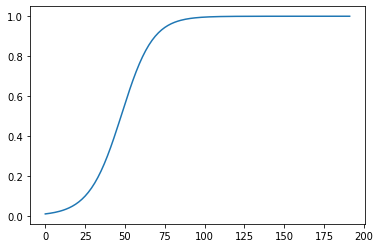

In [3]:
alpha = 1
beta = -1
dt = 0.1
x20 = 0.01

xs = [x20]
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))

plt.plot(xs)
#plt.ylim(None,1.05)
plt.show()

### Stability analysis

#### Phase space

In [4]:
def classify(alpha, beta):
    """Outcome class:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

# phase diagram
A = np.linspace(-2, 2, 401)
B = np.linspace(-2, 2, 401)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

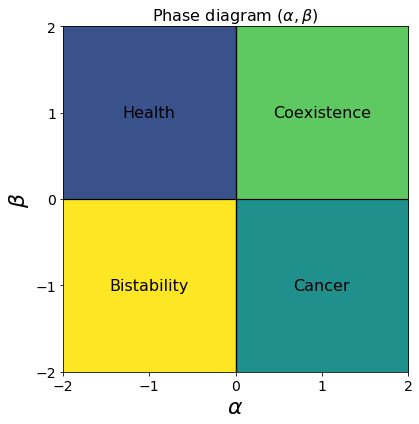

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(Z,origin='lower', extent=[A.min(), A.max(), B.min(), B.max()], aspect='equal')
ax.axhline(0, linewidth=1.2, color='black')
ax.axvline(0, linewidth=1.4, color='black')
ax.set(xticks=np.arange(-2,3),
       yticks=np.arange(-2,3),
       #xlabel=r'$\alpha$',
       #ylabel=r'$\beta$',
       #title=r'Phase diagram $(\alpha,\beta)$'
      )
ax.set_title(r'Phase diagram $(\alpha,\beta)$',fontsize=16)
ax.set_xlabel(r'$\alpha$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# or both
#ax.tick_params(labelsize=18)

# text
ax.text(-1, 1, 'Health', fontsize= 16, color='black', ha='center', va='center')
ax.text(1,1, 'Coexistence', fontsize= 16, color='black', ha='center', va='center')
ax.text(-1, -1, 'Bistability', fontsize= 16, color='black', ha='center', va='center')
ax.text(1, -1, 'Cancer', fontsize= 16, color='black', ha='center', va='center')

plt.tight_layout()
plt.savefig('phase_alpha_beta.png', dpi=300)
plt.show()

#### Examples params

In [6]:
def x_2(x2,alpha,beta,dt):
    return (x2*(1-x2)*(-(alpha+beta)*x2+alpha))*dt + x2

$\alpha<0, \beta>0$

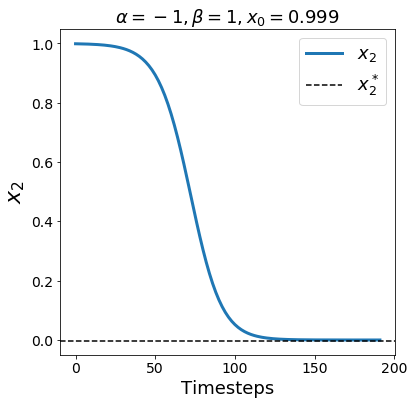

In [7]:
alpha = -1
beta = 1
dt = 0.1
x20 = 0.999

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3, label=r'$x_2$')
ax.axhline(-0.005,color='black', linestyle='--', label=r'$x_2^*$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.legend(fontsize=18)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta<0$

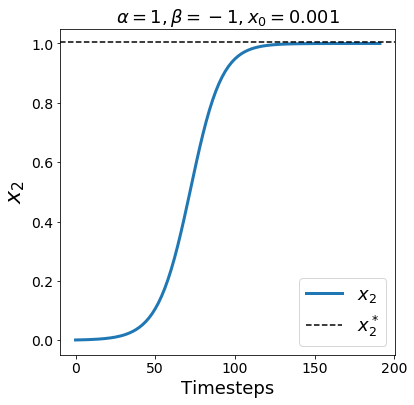

In [8]:
alpha = 1
beta = -1
dt = 0.1
x20 = 0.001

xs = [x20]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs.append(x_2(xs[-1],alpha,beta,dt))
    
ax.plot(xs,linewidth=3, label=r'$x_2$')
ax.axhline(1.005,color='black', linestyle='--', label=r'$x_2^*$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_0={x20}$', fontsize=18)
ax.legend(fontsize=18)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha>0, \beta>0$

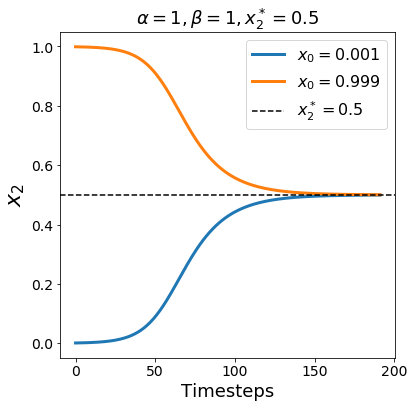

In [9]:
alpha = 1
beta = 1
dt = 0.1
xast = alpha/(alpha+beta)
x20_1 = 0.001
x20_2 = 0.999

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=r'$x_0=0.001$')
ax.plot(xs2,linewidth=3,label=r'$x_0=0.999$')
ax.axhline((xs1[-1]+xs2[-2])/2,color='black', linestyle='--', label=rf'$x_2^*={xast}$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*=0.5$', fontsize=18)
ax.legend(fontsize=16)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

$\alpha<0, \beta<0$

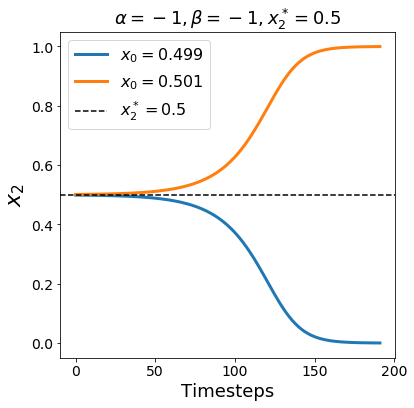

In [10]:
alpha = -1
beta = -1
dt = 0.1

xast = alpha/(alpha+beta)
x20_1 = alpha/(alpha+beta)-0.001
x20_2 = alpha/(alpha+beta)+0.001

xs1 = [x20_1]
xs2 = [x20_2]
fig, ax = plt.subplots(figsize=(6,6))
for t in np.arange(1, 20.0001, dt):
    xs1.append(x_2(xs1[-1],alpha,beta,dt))
    xs2.append(x_2(xs2[-1],alpha,beta,dt))
    
ax.plot(xs1,linewidth=3,label=rf'$x_0={x20_1:.3f}$')
ax.plot(xs2,linewidth=3,label=rf'$x_0={x20_2:.3f}$')
ax.axhline((x20_1+x20_2)/2,color='black', linestyle='--', label=rf'$x_2^*={xast}$')

ax.set_title(rf'$\alpha={alpha}, \beta={beta}, x_2^*={alpha/(alpha+beta):.1f}$', fontsize=18)
ax.legend(fontsize=16)

ax.set_xlabel('Timesteps', fontsize=18)
ax.set_ylabel(r'$x_2$', fontsize=22)
ax.tick_params(axis='x',labelsize=14)
ax.tick_params(axis='y',labelsize=14)
ax.set_ylim(None, 1.05)

plt.savefig(f'Figures/2-players_alpha_{alpha}_beta_{beta}.png', dpi=300)
plt.show()

## 2-players game with environmental feedback

\begin{equation}
    \begin{aligned}
        M(n) &= (1-f(n)) M_h + f(n)M_s \\
        f(n) &= \frac{n}{n+k} \\
        \dot{x_2} &= x_2(1-x_2)(-(\alpha(n)+\beta(n))+\alpha(n)) \\
        \dot{n} &= \epsilon x_2 - \mu n
    \end{aligned}
\end{equation}

In [17]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Ms_func(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

In [18]:
def Mh_func(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

### Hostile environment

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

$\alpha=0.5, \beta=0.6, \epsilon=0.16, \mu=0.02, k=0.1$

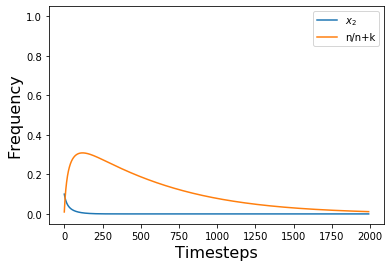

In [19]:
alpha = 0.5
beta = 0.6
eps = 0.16
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh, Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

$\alpha=0.5, \beta=0.6, \epsilon=0.23, \mu=0.02, k=0.1$

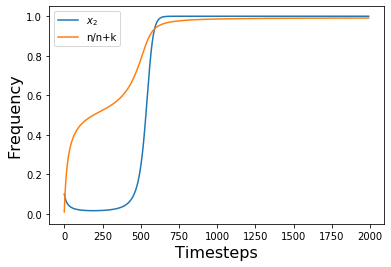

In [20]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.02
k = 0.1

dt = 0.1
x20 = 0.1
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

### Stable environment for coexistence

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way, the dynamics of the cancer cells population is,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \beta\left( \frac{n-k}{n+k}\right) x_2 + \alpha(1-x_2)\right)
\end{equation}

In [30]:
def x_full(x, alpha, beta, n, k, dt):
    return (x*(1-x)*(beta*((n-k)/(n+k))*x+alpha*(1-x)))*dt + x

In [21]:
def Mh_func(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

$\alpha=0.1, \beta=0.9, \epsilon=0.04, \mu=0.02, k=2$

#### Versión full

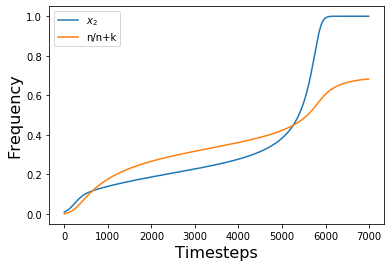

In [31]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    #M = Mn(f(k,ns[-1]), Mh,Ms)
    #alphan = M[1,0]
    #betan = M[0,1]
    xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

#### Versión modular

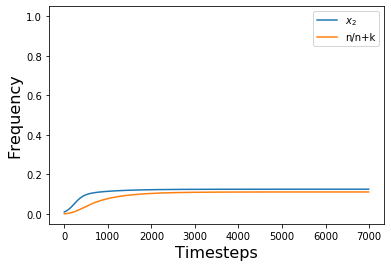

In [32]:
alpha = 0.1
beta = 0.9
eps = 0.04
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

$\alpha=0.1, \beta=0.9, \epsilon=0.09, \mu=0.02, k=2$

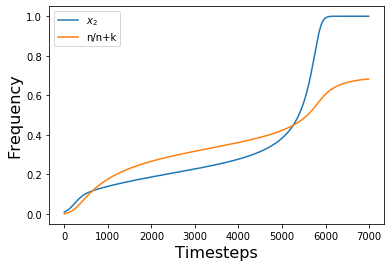

In [33]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 700.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    betan = M[0,1]
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

### Full algebraic version

In [372]:
def x_full(x, alpha, beta, n, k, dt):
    return (x*(1-x)*(beta*((n-k)/(n+k))*x+alpha*(1-x)))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

### Taylor

Taylor approximation for $\rho < k$ and close to $k$,
\begin{equation}
    x_2^* \approx x_2^*(k) + \frac{d x}{d \rho}_{\rho = k}(\rho - k)
\end{equation}
\begin{equation}
    x_2^* \approx 1 - \frac{\beta}{k(2\alpha - \beta)}(k-\rho)
\end{equation}

In [425]:
def x2_taylor(alpha, beta, k, rho):
    return (1 - beta / (k*(2*alpha-beta))*(k-rho))

### Internal branch

\begin{equation}
    \begin{aligned}
        x_2^*(\rho) &= \frac{2\alpha k}{\alpha (k-\rho)+\beta k +\sqrt{(\alpha(k-\rho)+\beta k)^2+4\rho(\alpha-\beta)\alpha k}}
    \end{aligned}
\end{equation}

In [426]:
def x_int(alpha, beta, k, rho):
    return 2*alpha*k / (alpha*(k-rho)+beta*k + np.sqrt((alpha*(k-rho)+beta*k)**2+4*rho*(alpha-beta)*alpha*k))

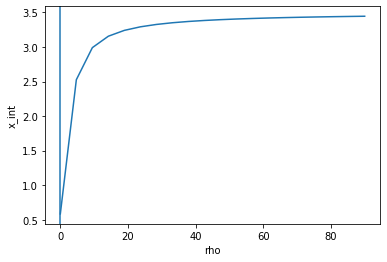

In [586]:
alpha = 0.7#0.1
beta = 0.5#0.9
epss = np.round(np.linspace(0.001, 0.9, 16),3)
mu = 0.01
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 1
rhos = epss / mu

#plt.plot(rhos, x_int(alpha, beta, k, rhos))
plt.plot(np.linspace(0,90,20), x_int(alpha, beta, k, np.linspace(0,90,20)))
plt.xlabel('rho')
plt.ylabel('x_int')
plt.axvline(mu*k)
plt.show()

In [579]:
np.linspace(0,6,20)

array([0.        , 0.31578947, 0.63157895, 0.94736842, 1.26315789,
       1.57894737, 1.89473684, 2.21052632, 2.52631579, 2.84210526,
       3.15789474, 3.47368421, 3.78947368, 4.10526316, 4.42105263,
       4.73684211, 5.05263158, 5.36842105, 5.68421053, 6.        ])

In [585]:
rhos

array([ 0.1,  6.1, 12.1, 18.1, 24.1, 30.1, 36.1, 42.1, 48. , 54. , 60. ,
       66. , 72. , 78. , 84. , 90. ])

In [587]:
x_int(alpha, beta, k, rhos)[-1]

3.444623070437686

In [588]:
# limit
alpha / (alpha - beta)

3.5000000000000004

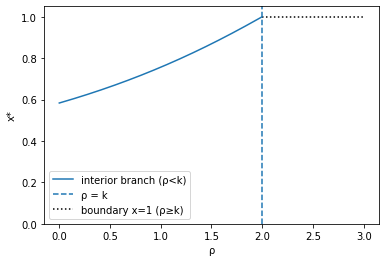

In [591]:
k = 2
def x_int(alpha, beta, k, rho):
    A = rho*(alpha-beta)
    B = alpha*(k-rho) + beta*k
    C = -alpha*k
    return 2*alpha*k / (B + np.sqrt(B**2 + 4*rho*(alpha-beta)*alpha*k))  # same as your formula

rhos = np.linspace(0, 1.5*k, 400)  # sweep up to 1.5*k
x_vals = x_int(alpha, beta, k, rhos)
x_vals = np.where(rhos < k, x_vals, np.nan)  # only show interior where it exists

plt.plot(rhos, x_vals, label='interior branch (ρ<k)')
plt.axvline(k, ls='--', label='ρ = k')
plt.hlines(1, k, rhos.max(), linestyles=':', label='boundary x=1 (ρ≥k)')
plt.ylim(0, 1.05)   # interior is in (0,1)
plt.xlabel('ρ'); plt.ylabel('x*'); plt.legend(); plt.show()


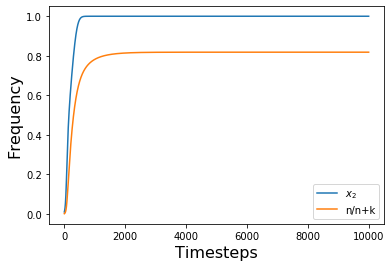

In [486]:
alpha = 0.5#0.1
beta = 0.5#0.9
eps = 0.09 #0.09
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

#Mh, Ms = Mh_func(alpha,beta), Ms_func(alpha,beta)

xs = [x20]
ns = [n0]

for t in np.arange(1, 1000.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

In [465]:
k, eps / mu

(5.0, 4.5)

In [466]:
x2_taylor(alpha, beta, k, rho)

0.9

In [467]:
x_int(alpha, beta, k, rho)

0.9090909090909091

In [468]:
xs[-1], ns[-1], rho*xs[-1]

(0.9090909013576103, 4.090909028556758, 4.090909056109246)

In [469]:
alpha / (alpha + beta)

0.5

In [470]:
k / (2*k - rho)

0.9090909090909091

/Users/guillermo/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


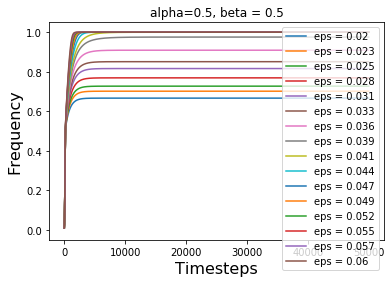

In [558]:
alpha = 0.5#0.1
beta = 0.5#0.9
epss = np.round(np.linspace(0.02, 0.06, 16),3)
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 2

dt = 0.1

xss = []
xints = []
for eps in epss:
    x20 = 0.01
    n0 = 0.001
    xs = [x20]
    ns = [n0]
    for t in np.arange(1, 5000.0001, dt):
        ns.append(n(ns[-1],xs[-1],eps,mu,dt))
        xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    xss.append(xs[-1])
    xints.append(x_int(alpha, beta, k, eps/mu))
    plt.title(f'alpha={alpha}, beta = {beta}')
    plt.plot(xs, label=f'eps = {eps}')
    #plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
    plt.legend()
    plt.xlabel('Timesteps',fontsize=16)
    plt.ylabel('Frequency',fontsize=16)
    plt.ylim(-0.05,1.05)
plt.show()

In [559]:
k*mu

0.04

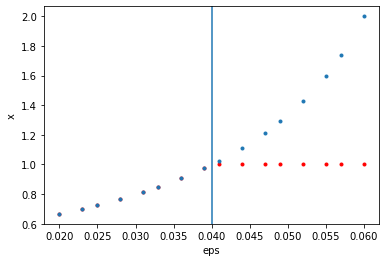

In [562]:
plt.plot(epss,xss, '.r')
plt.plot(epss,xints, '.')
plt.axvline(k*mu)
plt.ylabel('x')
plt.xlabel('eps')
plt.show()

In [574]:
np.array(xss)# - np.array(xints)

array([0.66666667, 0.70175439, 0.72727273, 0.76923077, 0.81632653,
       0.85106383, 0.90909091, 0.97560976, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [521]:
np.linspace(0.01, 0.06, 6)

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06])

/Users/guillermo/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


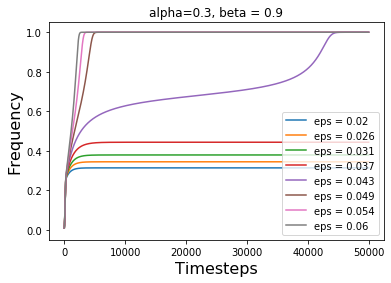

In [527]:
alpha = 0.3#0.1
beta = 0.9#0.9
epss = np.round(np.linspace(0.02, 0.06, 8),3)
mu = 0.02
#k = 4.5#2.3 #2.2 y 2.3 pasa el cambio
k = 2

dt = 0.1


for eps in epss:
    x20 = 0.01
    n0 = 0.001
    xs = [x20]
    ns = [n0]
    for t in np.arange(1, 5000.0001, dt):
        ns.append(n(ns[-1],xs[-1],eps,mu,dt))
        xs.append(x_full(xs[-1],alpha,beta,ns[-1],k,dt))
    plt.title(f'alpha={alpha}, beta = {beta}')
    plt.plot(xs, label=f'eps = {eps}')
    #plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
    plt.legend()
    plt.xlabel('Timesteps',fontsize=16)
    plt.ylabel('Frequency',fontsize=16)
    plt.ylim(-0.05,1.05)
plt.show()

In [520]:
# threshold
k*mu

0.04

### Summary coexistence section

In [ ]:
# ============================================================
# Replicator + Environmental Feedback — Figures (1)–(11)
# ============================================================
# This script generates a full figure set to present the
# analytics and intuition of the 2-strategy replicator with a
# Hill-like environmental feedback (via n, thresholded by k).
#
# Biology summary:
# - x in [0,1] is the cancer strategy frequency.
# - n is a toxin / environmental state, produced ~ eps*x, cleared ~ mu*n.
# - Control parameter: rho = eps/mu, normalized as rho_hat = rho/k.
# - Interior coexistence exists iff rho_hat < 1; at rho_hat = 1, the interior
#   collides with the boundary x=1; for rho_hat > 1, only x=1 remains.
#
# Libraries: numpy, matplotlib (no seaborn; one chart per figure)
# ============================================================

In [ ]:
# -----------------------------
# Core algebra (interior root)
# -----------------------------

In [647]:
def x_star_interior(alpha, beta, k, rho):
    """
    Algebraic interior root using the robust 'conjugate' quadratic form:
      x*(rho) = 2C / ( -B - sqrt(B^2 - 4AC) )
      where A = rho*(alpha - beta),
            B = alpha*(k - rho) + beta*k,
            C = -alpha*k

    Notes:
    - This returns the algebraic value for any rho.
    - The INTERIOR equilibrium is only *feasible* for rho < k (i.e., rho_hat < 1).
      Always mask your plot there to avoid the misleading continuation beyond 1.
    - We clamp the sqrt argument to >= 0 to avoid tiny negative roundoff.
    """
    A = rho * (alpha - beta)
    B = alpha * (k - rho) + beta * k
    C = -alpha * k
    inside = B**2 - 4.0 * A * C
    inside = np.maximum(inside, 0.0)
    return (2.0 * C) / (-B - np.sqrt(inside))

In [646]:
def x_star_linear_case(alpha, beta, k, rho):
    """
    Special linear case when alpha == beta:
      B x + C = 0 => x* = -C / B = k / (2k - rho)
    Valid as an algebraic expression whenever B != 0.
    Feasibility of interior still requires rho < k for x* in (0,1).
    """
    return k / (2.0 * k - rho)

In [644]:
def x_star(alpha, beta, k, rho, tol=1e-12):
    """
    Vectorized wrapper selecting the proper algebraic branch element-wise:
      - where |alpha - beta| < tol  -> linear case x* = k/(2k - rho)
      - else                         -> conjugate quadratic root

    alpha, beta, rho can be scalars or arrays (broadcasting supported).
    Returns an array broadcast to the common shape.
    """
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta,  dtype=float)
    rho   = np.asarray(rho,   dtype=float)

    alpha_b, beta_b, rho_b = np.broadcast_arrays(alpha, beta, rho)
    out = np.empty_like(rho_b, dtype=float)

    mask_linear = np.isclose(alpha_b - beta_b, 0.0, atol=tol)
    mask_quad   = ~mask_linear

    if np.any(mask_linear):
        out[mask_linear] = x_star_linear_case(alpha_b[mask_linear],
                                              beta_b[mask_linear],
                                              k, rho_b[mask_linear])
    if np.any(mask_quad):
        out[mask_quad] = x_star_interior(alpha_b[mask_quad],
                                         beta_b[mask_quad],
                                         k, rho_b[mask_quad])
    return out

In [645]:
def interior_exists(k, rho):
    """
    Existence of an interior equilibrium in (0,1) follows from endpoint signs:
      P(0) = -alpha*k < 0      (for alpha>0)
      P(1) = beta*(k - rho)
    => interior root in (0,1) iff rho < k.
    This condition is independent of alpha,beta beyond positivity.
    """
    return rho < k

In [648]:
def taylor_near_threshold(alpha, beta, k, rho):
    """
    1st-order Taylor approximation near the collision (from the left, rho -> k^-):
      x*(rho) ≈ 1 - [ beta / (k*(2*alpha - beta)) ] * (k - rho)

    Use only very close to rho = k and preferably when 2*alpha > beta
    (positive slope) — otherwise the linear term is not informative.
    """
    denom = k * (2.0 * alpha - beta)
    return 1.0 - (beta / denom) * (k - rho)

In [684]:
def x_nullcline_curve(alpha, beta, k, x):
    """
    Nontrivial x-nullcline q(x,n)=0 rearranged to n(x):
      n = k * [- alpha(1-x) + beta x] / [alpha(1-x) + beta x]
    (plus the vertical nullclines at x=0 and x=1 from the x(1-x) factor).
    """
    num = k * (- alpha * (1.0 - x) + beta * x)
    den = (alpha * (1.0 - x) + beta * x)
    return num / den

In [649]:
# -----------------------------
# Vector field + simulator
# -----------------------------

In [650]:
def f_x(x, n, alpha, beta, k):
    """
    Replicator RHS:
      dot{x} = x(1-x) [ alpha(1-x) + beta * h * x ],
      with h = (n - k)/(n + k) in (-1,1).
    Intuition:
      - alpha(1-x): benefit of cancer vs healthy under healthy-like environment.
      - beta*h*x: feedback shift once n exceeds k (environment turns cancer-favoring).
    """
    h = (n - k) / (n + k)
    return x * (1.0 - x) * (alpha * (1.0 - x) + beta * h * x)

In [651]:
def f_n(n, x, eps, mu):
    """
    Environmental toxin dynamics:
      dot{n} = eps * x - mu * n
    Steady state (for fixed x): n* = (eps/mu) * x = rho * x.
    """
    return eps * x - mu * n

In [652]:
def simulate(alpha, beta, eps, mu, k, x0=0.01, n0=0.0, T=200.0, dt=0.01):
    """
    Explicit Euler integrator for the 2D system (x(t), n(t)).
    Keeps x in [0,1] and n >= 0 by clipping (biological domain).
    """
    steps = int(T / dt)
    xs = np.empty(steps + 1); ns = np.empty(steps + 1); ts = np.empty(steps + 1)
    xs[0] = x0; ns[0] = n0; ts[0] = 0.0
    for i in range(steps):
        x = xs[i]; n = ns[i]
        #xs[i+1] = np.clip(x + dt * f_x(x, n, alpha, beta, k), 0.0, 1.0)
        xs[i+1] = x + dt * f_x(x, n, alpha, beta, k)
        #ns[i+1] = max(n + dt * f_n(n, x, eps, mu), 0.0)
        ns[i+1] = n + dt * f_n(n, x, eps, mu)
        ts[i+1] = ts[i] + dt
    return ts, xs, ns

In [ ]:
# -----------------------------
# Figure 1 — Bifurcation diagram x*(rho_hat)
# -----------------------------

def make_fig_1(alpha, beta, k):
    """
    Figure 1 — Bifurcation diagram: x*(rho_hat) vs rho_hat = rho/k.
    Interior exists only for rho_hat < 1; collision at rho_hat = 1; boundary x=1 beyond.

    Why: This is the central 'tipping' picture. It shows coexistence giving way to dominance.
    """
    rho_hat = np.linspace(0.0, 1.5, 400)
    rho = rho_hat * k
    x_alg = x_star(alpha, beta, k, rho)
    x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)  # mask beyond threshold

    plt.figure()
    plt.plot(rho_hat, x_plot, label='interior branch (rho_hat < 1)')
    plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
    plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
    plt.ylim(0, 1.05)
    plt.xlabel(r'$\hat{\rho}=\rho/k$')
    plt.ylabel(r'$x^*$')
    plt.title('Bifurcation diagram: interior branch and boundary collision')
    plt.legend()
    plt.show()

In [662]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs

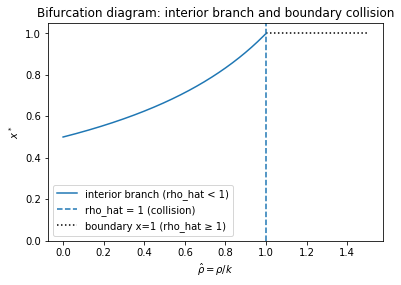

In [663]:
# 1) Bifurcation diagram
make_fig_1(alpha, beta, k)

In [730]:
np.linspace(0,1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

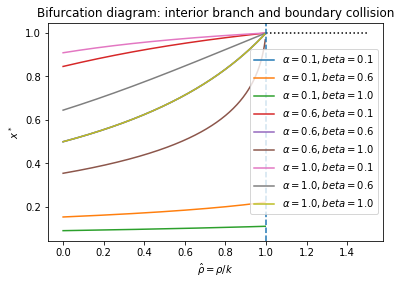

In [735]:
alphas = np.linspace(0.1,1, 3)
betas = np.linspace(0.1,1, 3)
for alpha in alphas:
    for beta in betas:
        rho_hat = np.linspace(0.0, 1.5, 400)
        rho = rho_hat * k
        x_alg = x_star(alpha, beta, k, rho)
        x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)  # mask beyond threshold

        #plt.figure()
        plt.plot(rho_hat, x_plot, label=fr'$\alpha={alpha:.1f}, beta={beta:.1f}$')
        #plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
        #plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
        #plt.ylim(0, 1.05)
        plt.xlabel(r'$\hat{\rho}=\rho/k$')
        plt.ylabel(r'$x^*$')
        plt.title('Bifurcation diagram: interior branch and boundary collision')
        plt.legend()

plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
plt.show()

In [685]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs

In [714]:
# -----------------------------
# Figures 2 & 3 — Nullclines
# -----------------------------

def make_fig_2(alpha, beta, k, rho_hat=0.7):
    """
    Figure 2 — Nullclines snapshot for rho_hat < 1 (interior exists).
    """
    rho = rho_hat * k
    xgrid = np.linspace(1e-6, 1.0-1e-6, 1000)
    n_curve = x_nullcline_curve(alpha, beta, k, xgrid)
    n_line  = rho * xgrid

    # Vertical asymptote
    x_asym = alpha / (alpha + beta)

    plt.figure()
    plt.plot(xgrid, n_curve, label='x-nullcline (q(x,n)=0)')
    plt.plot(xgrid, n_line,  label=r'$n$-nullcline: $n=\rho x$')
    if 0.0 < x_asym < 1.0:
        plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')
    plt.xlabel('x'); plt.ylabel('n')
    #plt.ylim(0, None)  # enforce n ≥ 0
    plt.title(f'Nullclines (coexistence): $\\hat{{\\rho}}={rho_hat:.2f}<1$')
    plt.legend()
    plt.show()

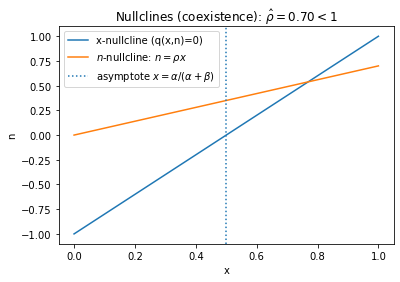

In [715]:
# 2) Nullclines: coexistence snapshot (rho_hat < 1)
make_fig_2(alpha, beta, k, rho_hat=0.7)

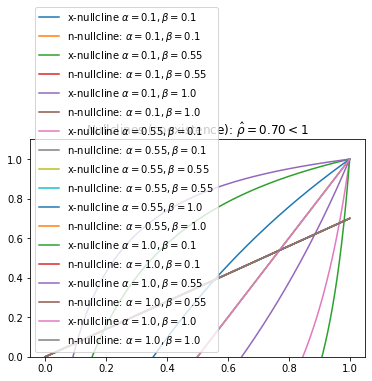

In [734]:
rho_hat=0.7
alphas = np.linspace(0.1,1, 3)
betas = np.linspace(0.1,1, 3)
for alpha in alphas:
    for beta in betas:
        rho = rho_hat * k
        xgrid = np.linspace(1e-6, 1.0-1e-6, 1000)
        n_curve = x_nullcline_curve(alpha, beta, k, xgrid)
        n_line  = rho * xgrid

        # Vertical asymptote
        #x_asym = alpha / (alpha + beta)

        #plt.figure()
        plt.plot(xgrid, n_curve, label=fr'x-nullcline $\alpha={alpha}, \beta={beta}$')
        plt.plot(xgrid, n_line,  label=fr'n-nullcline: $\alpha={alpha}, \beta={beta}$')
        """
        if 0.0 < x_asym < 1.0:
            plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')
        plt.xlabel('x'); plt.ylabel('n')
        """
        plt.ylim(0, None)  # enforce n ≥ 0
        plt.title(f'Nullclines (coexistence): $\\hat{{\\rho}}={rho_hat:.2f}<1$')
plt.legend()
plt.show()

In [706]:
def make_fig_3(alpha, beta, k, rho_hat=1.3):
    """
    Figure 3 — Nullclines snapshot for rho_hat > 1 (no interior).
    Shows only the feasible branch n>=0 of the x-nullcline, shades n<0, and
    marks the vertical asymptote at x = alpha/(alpha+beta).
    """
    rho = rho_hat * k
    xgrid = np.linspace(1e-6, 1.0-1e-6, 2000)

    # x-nullcline curve: n(x) = k*(alpha(1-x) - beta x) / (alpha(1-x) + beta x)
    n_curve = x_nullcline_curve(alpha, beta, k, xgrid)

    # Feasible part (biology): n >= 0
    feasible = n_curve >= 0

    # n-nullcline line: n = rho * x
    n_line  = rho * xgrid

    # Vertical asymptote where alpha(1-x) + beta x = 0  ->  x = alpha/(alpha+beta)
    x_asym = alpha / (alpha + beta)

    plt.figure()

    # Shade the infeasible region (n < 0) lightly for context
    plt.fill_between([0, 1], 0, -1, color='0.95')

    # Plot only the feasible branch of the x-nullcline
    plt.plot(xgrid[feasible], n_curve[feasible], label='x-nullcline (feasible n ≥ 0)')

    # Optionally show the infeasible branch as faint dashed
    if np.any(~feasible):
        plt.plot(xgrid[~feasible], n_curve[~feasible], ls='--', alpha=0.4,
                 label='x-nullcline (infeasible n < 0)')

    # Plot n-nullcline (keep mathtext here; it’s correct)
    plt.plot(xgrid, n_line,  label=r'$n$-nullcline: $n=\rho x$')

    # Mark the vertical asymptote (if within [0,1])
    if 0.0 < x_asym < 1.0:
        plt.axvline(x_asym, ls=':', label=r'asymptote $x=\alpha/(\alpha+\beta)$')

    plt.xlabel('x'); plt.ylabel('n')
    #plt.ylim(0, None)  # biological range for n
    plt.title(f'Nullclines (no interior): $\\hat{{\\rho}}={rho_hat:.2f}>1$')
    plt.legend()
    plt.show()

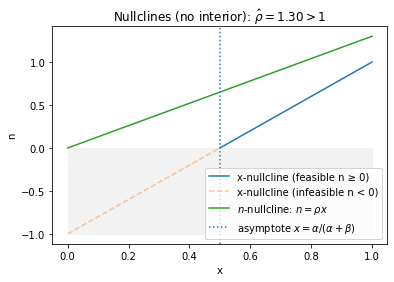

In [707]:
# 3) Nullclines: no-interior snapshot (rho_hat > 1)
make_fig_3(alpha, beta, k, rho_hat=1.3)

In [736]:
# -----------------------------
# Figure 4 — Feasibility map (same as Fig.1, emphasis on masking)
# -----------------------------

def make_fig_4(alpha, beta, k):
    """
    Figure 4 — Feasibility map: interior branch masked for rho_hat >= 1, boundary shown beyond.
    Why: Reader sees at a glance where the coexistence branch is defined and where it is not.
    """
    rho_hat = np.linspace(0.0, 1.5, 400)
    rho = rho_hat * k
    x_alg = x_star(alpha, beta, k, rho)
    x_plot = np.where(rho_hat < 1.0, x_alg, np.nan)

    plt.figure()
    plt.plot(rho_hat, x_plot, label='interior branch (rho_hat < 1)')
    plt.axvline(1.0, linestyle='--', label='rho_hat = 1 (collision)')
    plt.hlines(1.0, 1.0, rho_hat.max(), linestyles=':', label='boundary x=1 (rho_hat ≥ 1)')
    plt.ylim(0, 1.05)
    plt.xlabel(r'$\hat{\rho}$'); plt.ylabel('x')
    plt.title('Feasibility map: interior exists only for $\\hat{\\rho}<1$')
    plt.legend()
    plt.show()

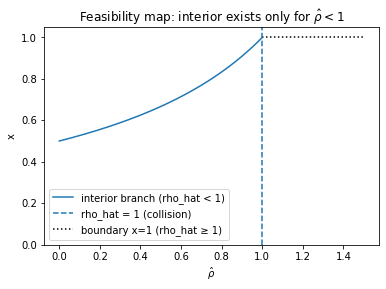

In [737]:
# 4) Feasibility map
make_fig_4(alpha, beta, k)

In [738]:
# -----------------------------
# Figure 5 — x*(rho_hat) vs payoff mix r
# -----------------------------

def make_fig_5(k, rho_hats=(0.2, 0.5, 0.8)):
    """
    Figure 5 — x*(rho_hat) vs r = alpha/(alpha+beta), for several rho_hat < 1.
    Why: Shows how payoff asymmetry (composition r) tilts coexistence composition at fixed load.

    Implementation:
    - Fix total payoff scale s=1 (just sets timescale) and sweep r in (0,1).
    - For each rho_hat<1, compute algebraic x* and mask if needed (though rho_hat is fixed <1 here).
    """
    r = np.linspace(1e-3, 1.0-1e-3, 300)  # avoid endpoints
    plt.figure()
    for rh in rho_hats:
        rho = rh * k
        s = 1.0
        alpha = r * s
        beta  = (1.0 - r) * s
        x_alg = x_star(alpha, beta, k, rho)
        x_plot = np.where(rh < 1.0, x_alg, np.nan)
        plt.plot(r, x_plot, label=f'rho_hat={rh:.2f}')
    plt.xlabel(r'$r=\alpha/(\alpha+\beta)$'); plt.ylabel(r'$x^*$')
    plt.title('Coexistence composition vs payoff mix (only for $\\hat{\\rho}<1$)')
    plt.legend()
    plt.show()

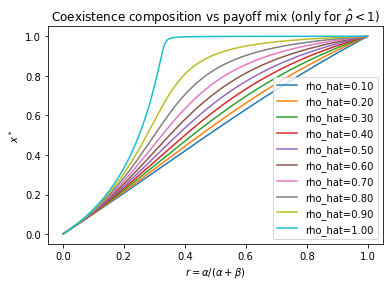

In [749]:
# 5) x*(rho_hat) vs payoff mix r at several rho_hat < 1
make_fig_5(k, rho_hats=np.linspace(0.1,0.999,10))

In [ ]:
# -----------------------------
# Figure 6 — No-feedback quadrant map (schematic)
# -----------------------------

def make_fig_6():
    """
    Figure 6 — No-feedback (alpha,beta) schematic quadrant map.
    Why: Provides context — classical 2x2 game outcomes without environmental coupling.
    """
    plt.figure()
    plt.axhline(0.0, linestyle='--', color='black')
    plt.axvline(0.0, linestyle='--', color='black')
    plt.text( 0.5,  0.5, 'Coexistence\n$(\\alpha>0,\\,\\beta>0)$', ha='center', va='center')
    plt.text(-0.5,  0.5, 'Strategy 1 dominates\n$(\\alpha<0,\\,\\beta>0)$', ha='center', va='center')
    plt.text( 0.5, -0.5, 'Strategy 2 dominates\n$(\\alpha>0,\\,\\beta<0)$', ha='center', va='center')
    plt.text(-0.5, -0.5, 'Bistability\n$(\\alpha<0,\\,\\beta<0)$', ha='center', va='center')
    plt.xlim(-1, 1); plt.ylim(-1, 1)
    plt.xlabel('$\\alpha$'); plt.ylabel('$\\beta$')
    plt.title('No-feedback game outcome map (schematic)')
    plt.show()

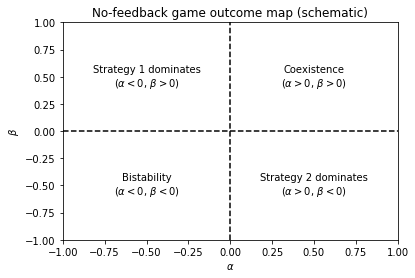

In [750]:
# Baseline parameters:
k = 1.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 6) No-feedback quadrant map (schematic)
make_fig_6()

In [751]:
# -----------------------------
# Figure 7 — Heatmap of x*(rho_hat, r)
# -----------------------------

def make_fig_7(k, s=1.0, N_r=100, N_rho=120):
    """
    Figure 7 — Heatmap of the interior equilibrium x*(rho_hat, r).
    Why: Compact global view: environmental load (horizontal) vs payoff mix (vertical)
         determining the coexistence composition.

    Implementation:
    - Compute only for rho_hat < 1; mask (NaN) elsewhere.
    """
    rho_hat = np.linspace(0.0, 1.2, N_rho)
    r = np.linspace(1e-3, 1.0-1e-3, N_r)
    XX = np.zeros((N_r, N_rho))
    for i, ri in enumerate(r):
        alpha = ri * s
        beta  = (1.0 - ri) * s
        rho = rho_hat * k
        x_alg = x_star(alpha, beta, k, rho)
        x_alg = np.where(rho_hat < 1.0, x_alg, np.nan)
        XX[i, :] = x_alg

    plt.figure()
    im = plt.imshow(XX, aspect='auto', origin='lower',
                    extent=[rho_hat[0], rho_hat[-1], r[0], r[-1]])
    plt.axvline(1.0, linestyle='--', color='black')
    plt.xlabel(r'$\hat{\rho}$'); plt.ylabel(r'$r=\alpha/(\alpha+\beta)$')
    plt.title(r'Heatmap of $x^*(\hat{\rho}, r)$ (masked for $\hat{\rho}\geq 1$)')
    plt.colorbar(im, label=r'$x^*$')
    plt.show()

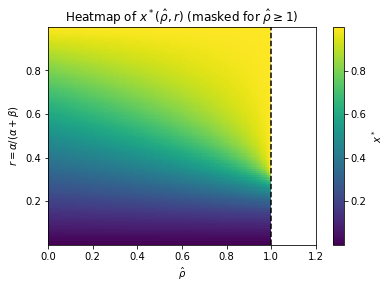

In [756]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 7) Heatmap of x*(rho_hat, r)
make_fig_7(k, s=1.0) # invariant to k?

In [758]:
# -----------------------------
# Figure 8 — Heatmap of interior stability
# -----------------------------

def interior_stability_sign(alpha, beta, k, rho):
    """
    Sign of the x-eigenvalue at the interior fixed point (local stability of x):
      lambda_x = x*(1-x) * ( beta*h - alpha ), with
      h = (n* - k)/(n* + k),  n* = rho * x*.

    Stability condition: lambda_x < 0  <=>  beta*h - alpha < 0.

    Returns:
      -1 for stable, +1 for unstable/saddle, NaN when interior does not exist.
    """
    if not interior_exists(k, rho):
        return np.nan
    x = x_star(alpha, beta, k, rho)
    n = rho * x
    h = (n - k) / (n + k)
    val = beta * h - alpha
    return -1.0 if val < 0.0 else 1.0

def make_fig_8(k, s=1.0, N_r=120, N_rho=140):
    """
    Figure 8 — Stability map (rho_hat, r): stable (-1) vs unstable/saddle (+1),
    masked for rho_hat >= 1.

    Why: Shows where coexistence is not just present but attracting.
    """
    rho_hat = np.linspace(0.0, 1.2, N_rho)
    r = np.linspace(1e-3, 1.0-1e-3, N_r)
    SS = np.zeros((N_r, N_rho)); SS[:] = np.nan
    for i, ri in enumerate(r):
        alpha = ri * s
        beta  = (1.0 - ri) * s
        for j, rh in enumerate(rho_hat):
            rho = rh * k
            SS[i, j] = interior_stability_sign(alpha, beta, k, rho)

    plt.figure()
    im = plt.imshow(SS, aspect='auto', origin='lower',
                    extent=[rho_hat[0], rho_hat[-1], r[0], r[-1]])
    plt.axvline(1.0, linestyle='--', color='black')
    plt.xlabel(r'$\hat{\rho}$'); plt.ylabel(r'$r$')
    plt.title('Interior stability: stable (-1) vs saddle (+1); masked for $\\hat{\\rho}\\geq 1$')
    plt.colorbar(im, label='stability sign')
    plt.show()

In [778]:
def interior_stability_sign(alpha, beta, k, rho, eps, mu):
    """
    Classify interior equilibrium stability using the full 2x2 Jacobian.
    Returns:
      -1.0 : stable (both eigenvalues have negative real parts)
      +1.0 : unstable (node/focus) or saddle
       np.nan : no interior equilibrium (rho >= k or x* not in (0,1))
    """
    # Feasibility gate: interior exists only if rho < k
    if rho >= k:
        return np.nan

    # Compute interior fixed point x* (use your branch that stays finite as rho->0)
    x = x_star(alpha, beta, k, rho)  # your robust algebraic branch
    if not (0.0 < x < 1.0):
        return np.nan

    n = rho * x
    h = (n - k) / (n + k)                 # feedback factor
    dh_dn = 2.0 * k / (n + k)**2          # derivative of h

    # Shorthands
    g  = beta * h * x + alpha * (1.0 - x) # bracket in dot{x}
    dx = (1.0 - 2.0 * x) * g + x * (1.0 - x) * (beta * h - alpha)
    dn = x**2 * (1.0 - x) * beta * dh_dn

    tr  = dx - mu
    det = (-mu) * dx - eps * dn

    if det < 0.0:
        return 1.0  # saddle (unstable)
    # det >= 0: sign of trace decides
    return -1.0 if tr < 0.0 else 1.0

In [782]:
def make_fig_8(k, eps, mu, s=1.0, N_r=120, N_rho=140):
    rho_hat = np.linspace(0.0, 1.2, N_rho)
    r = np.linspace(1e-3, 1.0-1e-3, N_r)
    SS = np.full((N_r, N_rho), np.nan)
    for i, ri in enumerate(r):
        alpha = ri * s
        beta  = (1.0 - ri) * s
        for j, rh in enumerate(rho_hat):
            rho = rh * k
            SS[i, j] = interior_stability_sign(alpha, beta, k, rho, eps, mu)

    plt.figure()
    im = plt.imshow(SS, aspect='auto', origin='lower',
                    extent=[rho_hat[0], rho_hat[-1], r[0], r[-1]])
    plt.axvline(1.0, linestyle='--', color='black')
    plt.xlabel(r'$\hat{\rho}$'); plt.ylabel(r'$r$')
    title_txt = (r'Interior stability: stable (-1) vs unstable/saddle (+1); '
                 r'masked for $\hat{\rho}\geq 1$')
    plt.title(title_txt)
    plt.colorbar(im, label='stability sign')
    plt.show()

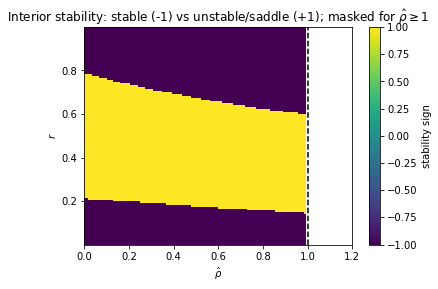

In [788]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.03, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

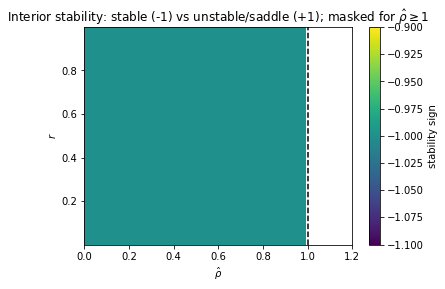

In [785]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.02, 0.08
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

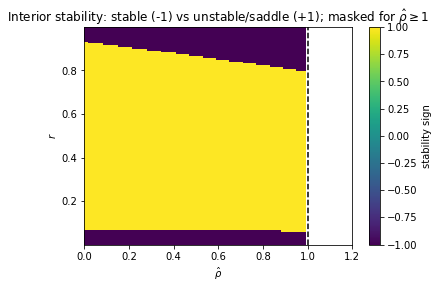

In [786]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.08, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

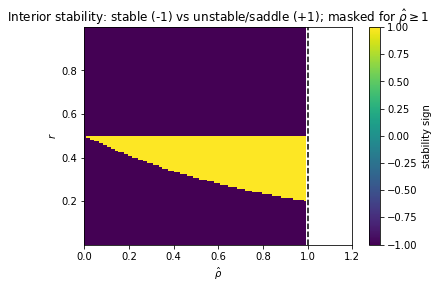

In [790]:
# Baseline parameters:
k = 2.0                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
#eps, mu = 0.02, 0.03
eps, mu = 0.04, 0.01
# 8) Heatmap of interior stability
make_fig_8(k, eps, mu, s=1.0)

In [761]:
# -----------------------------
# Figures 9 & 10 — Time traces
# -----------------------------

def make_fig_9(alpha, beta, k, eps, mu, x0=0.01, n0=0.0):
    """
    Figure 9 — Time traces when rho_hat < 1 (coexistence).
    Why: Dynamics example converging to the interior fixed point (x*, n* = rho x*).
    """
    rho_hat = (eps / mu) / k
    ts, xs, ns = simulate(alpha, beta, eps, mu, k, x0=x0, n0=n0, T=400.0, dt=0.01)
    plt.figure()
    plt.plot(ts, xs, label='x(t)')
    plt.plot(ts, ns, label='n(t)')
    plt.xlabel('time'); plt.ylabel('state')
    plt.title(f'Dynamics to coexistence ( $\\hat{{\\rho}}={rho_hat:.2f}<1$ )')
    plt.legend()
    plt.show()

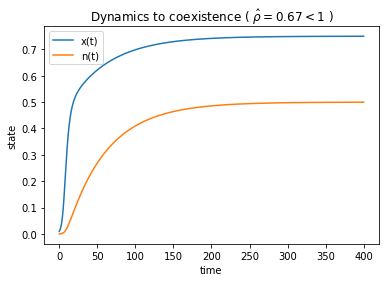

In [769]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 9) Time traces — pick eps, mu so rho_hat = (eps/(mu*k)) < 1
eps, mu = 0.02, 0.03    # rho_hat = (0.02/0.03)/1 ≈ 0.666...
make_fig_9(alpha, beta, k, eps, mu)

In [770]:
def make_fig_10(alpha, beta, k, eps, mu, x0=0.01, n0=0.0):
    """
    Figure 10 — Time traces when rho_hat > 1 (dominance).
    Why: Dynamics example converging to boundary x=1.
    """
    rho_hat = (eps / mu) / k
    ts, xs, ns = simulate(alpha, beta, eps, mu, k, x0=x0, n0=n0, T=200.0, dt=0.01)
    plt.figure()
    plt.plot(ts, xs, label='x(t)')
    plt.plot(ts, ns, label='n(t)')
    plt.xlabel('time'); plt.ylabel('state')
    plt.title(f'Dynamics to dominance ( $\\hat{{\\rho}}={rho_hat:.2f}>1$ )')
    plt.legend()
    plt.show()

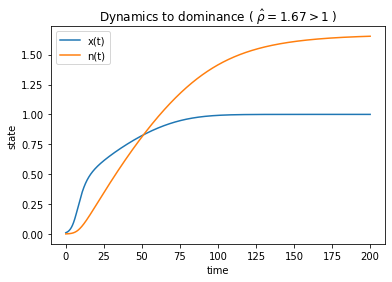

In [771]:
# Baseline parameters:
k = 1                       # environmental tolerance
alpha, beta = 0.5, 0.5        # balanced payoffs
# 10) Time traces — pick eps, mu so rho_hat > 1
eps, mu = 0.05, 0.03    # rho_hat ≈ 1.666...
make_fig_10(alpha, beta, k, eps, mu)

In [772]:
# -----------------------------
# Figure 11 — (epsilon, mu) parameter-plane threshold
# -----------------------------

def make_fig_11(k, mu_range=(0.005, 0.06), eps_range=(0.005, 0.06), N=200):
    """
    Figure 11 — Parameter-plane (epsilon, mu) with threshold line epsilon = mu*k.
    Why: Direct handle for experimentalists — how production (eps) vs recovery (mu)
         must scale to remain under the tipping line (coexistence possible when eps < mu*k).
    """
    mu_vals = np.linspace(mu_range[0], mu_range[1], N)
    # Just plot the threshold line; annotate regions
    plt.figure()
    plt.plot(mu_vals, k * mu_vals, label=r'$\epsilon=\mu k$ (threshold)')
    plt.xlabel(r'$\mu$ (recovery)'); plt.ylabel(r'$\epsilon$ (production)')
    plt.title('Parameter-plane threshold: coexistence if $\\epsilon < \\mu k$')
    # Annotations (plain text to avoid mathtext headaches)
    plt.text(mu_vals[0], k * mu_vals[0] * 0.6, 'coexistence possible\n(ε < μ k)')
    plt.text(mu_vals[-1]*0.6, k * mu_vals[-1]*1.1, 'dominance region\n(ε > μ k)')
    plt.legend()
    plt.show()

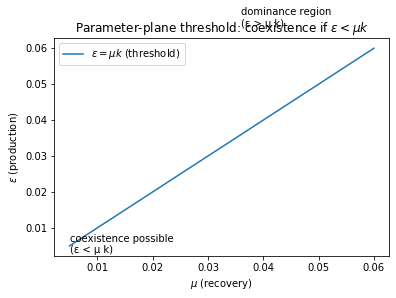

In [773]:
# 11) (epsilon, mu) plane with epsilon = mu*k
make_fig_11(k, mu_range=(0.005, 0.06), eps_range=(0.005, 0.06))

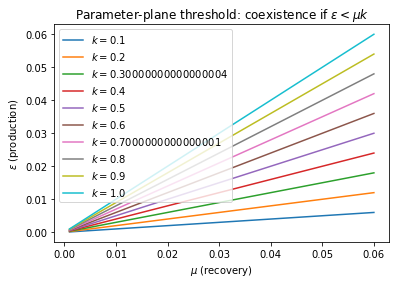

In [777]:
N = 200
mu_range=(0.001, 0.06)
eps_range=(0.001, 0.06)
ks = np.linspace(0.1,1,10)
for k in ks:
    mu_vals = np.linspace(mu_range[0], mu_range[1], N)
    # Just plot the threshold line; annotate regions
    #plt.figure()
    plt.plot(mu_vals, k * mu_vals, label=fr'$k={k}$')
plt.xlabel(r'$\mu$ (recovery)'); plt.ylabel(r'$\epsilon$ (production)')
plt.title('Parameter-plane threshold: coexistence if $\\epsilon < \\mu k$')
    # Annotations (plain text to avoid mathtext headaches)
    #plt.text(mu_vals[0], k * mu_vals[0] * 0.6, 'coexistence possible\n(ε < μ k)')
    #plt.text(mu_vals[-1]*0.6, k * mu_vals[-1]*1.1, 'dominance region\n(ε > μ k)')
plt.legend()
plt.show()